In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
Original_df = pd.read_csv('diabetic_data.csv')
df = Original_df.copy()
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [69]:
df.shape

(101766, 30)

In [3]:
df2 = pd.read_csv('IDS_mapping.csv')
df2.head()

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available


In [4]:
df2.shape

(67, 2)

In [5]:
pd.set_option('display.max_columns',None)
# pd.set_option('display.max_rows',None)

In [6]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [8]:
df.isna().sum()[df.isna().sum() != 0]

max_glu_serum    96420
A1Cresult        84748
dtype: int64

In [9]:
df[df.duplicated()]

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted


In [10]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [11]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [12]:
df = df.drop(columns=['encounter_id','patient_nbr','payer_code'])

In [13]:
df.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),?,6,25,1,1,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),?,1,1,7,3,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),?,1,1,7,2,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),?,1,1,7,1,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [14]:
df['race'] = df['race'].replace('?','Unknown')

In [15]:
def covert_range_tosingle_value(age):
    if age == '[0-10)':
        return 5
    if age == '[10-20)':
        return 15
    if age == '[20-30)':
        return 25
    if age == '[30-40)':
        return 35
    if age == '[40-50)':
        return 45
    if age == '[50-60)':
        return 55
    if age == '[60-70)':
        return 65
    if age == '[70-80)':
        return 75
    if age == '[80-90)':
        return 85
    if age == '[90-100)':
        return 95
    

In [16]:
df['gender'].value_counts()

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

In [17]:
df['gender'] = df['gender'].replace('Unknown/Invalid',np.nan)

In [18]:
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

In [19]:
df['age'] = df['age'].apply(covert_range_tosingle_value)

In [20]:
def covert_range_tosingle_value2(weight):
    if weight == '[0-25)':
        return (0+25)/2
    if weight == '[25-50)':
        return (25+50)/2
    if weight == '[50-75)':
        return (50+75)/2
    if weight == '[75-100)':
        return (75+100)/2
    if weight == '[100-125)':
        return (100+125)/2
    if weight == '[125-150)':
        return (125+150)/2
    if weight == '[150-175)':
        return (150+175)/2
    if weight == '[175-200)':
        return (175+200)/2
    if weight == '>200':
        return np.nan
    if weight == '?':
        return np.nan
    

In [21]:
df['weight'] = df['weight'].apply(covert_range_tosingle_value2)

In [22]:
df['weight'] = df['weight'].fillna(df['weight'].median())

In [23]:
df['weight'].value_counts()

weight
87.5     99908
62.5       897
112.5      625
137.5      145
37.5        97
12.5        48
162.5       35
187.5       11
Name: count, dtype: int64

In [24]:
df.drop(columns='medical_specialty',inplace=True)

In [25]:
df['num_procedures'].isna().sum()

np.int64(0)

In [26]:
df['diag_1'] = df['diag_1'].replace('?', 'Unknown')
df['diag_2'] = df['diag_2'].replace('?', 'Unknown')
df['diag_3'] = df['diag_3'].replace('?', 'Unknown')

In [27]:
df.drop('max_glu_serum', axis=1, inplace=True)

In [28]:
df.drop(columns='A1Cresult',inplace=True)

In [29]:
df = df.drop(columns=['acetohexamide','chlorpropamide','tolbutamide','acarbose','miglitol','troglitazone','tolazamide','examide','citoglipton','glyburide-metformin','glipizide-metformin','glimepiride-pioglitazone','metformin-rosiglitazone','metformin-pioglitazone'])

In [30]:
df.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,insulin,change,diabetesMed,readmitted
0,Caucasian,Female,5,87.5,6,25,1,1,41,0,1,0,0,0,250.83,Unknown,Unknown,1,No,No,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,15,87.5,1,1,7,3,59,0,18,0,0,0,276,250.01,255,9,No,No,No,No,No,No,No,No,Up,Ch,Yes,>30
2,AfricanAmerican,Female,25,87.5,1,1,7,2,11,5,13,2,0,1,648,250,V27,6,No,No,No,No,Steady,No,No,No,No,No,Yes,NO
3,Caucasian,Male,35,87.5,1,1,7,2,44,1,16,0,0,0,8,250.43,403,7,No,No,No,No,No,No,No,No,Up,Ch,Yes,NO
4,Caucasian,Male,45,87.5,1,1,7,1,51,0,8,0,0,0,197,157,250,5,No,No,No,No,Steady,No,No,No,Steady,Ch,Yes,NO


In [31]:
df.to_csv("first_cleaned.cvs",index=False)

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 30 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   race                      101766 non-null  str    
 1   gender                    101766 non-null  str    
 2   age                       101766 non-null  int64  
 3   weight                    101766 non-null  float64
 4   admission_type_id         101766 non-null  int64  
 5   discharge_disposition_id  101766 non-null  int64  
 6   admission_source_id       101766 non-null  int64  
 7   time_in_hospital          101766 non-null  int64  
 8   num_lab_procedures        101766 non-null  int64  
 9   num_procedures            101766 non-null  int64  
 10  num_medications           101766 non-null  int64  
 11  number_outpatient         101766 non-null  int64  
 12  number_emergency          101766 non-null  int64  
 13  number_inpatient          101766 non-null  int64  
 14 

In [33]:
(df == '?').sum().sort_values(ascending=False)

race                        0
gender                      0
age                         0
weight                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
metformin                   0
repaglinide                 0
nateglinide                 0
glimepiride                 0
glipizide                   0
glyburide                   0
pioglitazone                0
rosiglitazone               0
insulin                     0
change                      0
diabetesMed                 0
readmitted                  0
dtype: int64

### EDA

<Axes: >

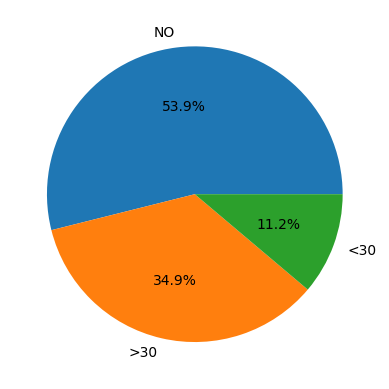

In [34]:
df['readmitted'].value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: xlabel='readmitted', ylabel='age'>

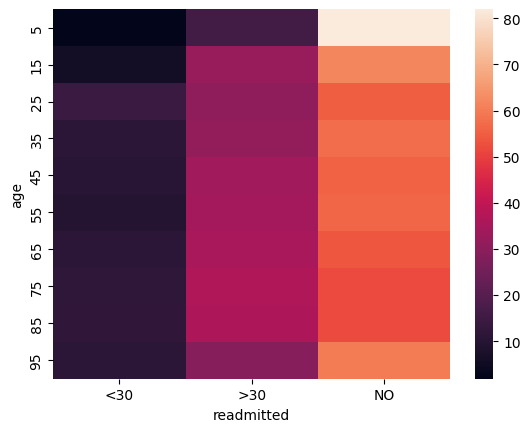

In [35]:
sns.heatmap(pd.crosstab(df['age'], df['readmitted'], normalize='index') * 100)

In [36]:
pd.crosstab(df['age'], df['readmitted'], normalize='index') * 100

readmitted,<30,>30,NO
age,,,
5,1.863354,16.149068,81.987578
15,5.788712,32.416787,61.794501
25,14.242607,30.778515,54.978877
35,11.231788,31.443709,57.324503
45,10.604027,33.846154,55.549819
55,9.666203,34.289522,56.044274
65,11.128408,35.124316,53.747276
75,11.773055,36.347246,51.879699
85,12.083503,36.186544,51.729953


In [37]:
pd.crosstab(df['number_inpatient'], df['readmitted'], normalize='index') * 100


readmitted,<30,>30,NO
number_inpatient,,,
0,8.437084,30.057667,61.505249
1,12.924543,41.836996,45.238461
2,17.433254,47.501983,35.064763
3,20.287306,49.428320,30.284374
4,23.612824,50.616523,25.770654
5,31.403941,48.645320,19.950739
6,34.583333,49.583333,15.833333
7,35.447761,45.522388,19.029851
8,44.370861,46.357616,9.271523


So previous inpatient visits increase hone ke saath 30-day readmission ka rate generally increase ho raha hai.

In [38]:
pd.crosstab(df['number_emergency'], df['readmitted'], normalize='index') * 100

readmitted,<30,>30,NO
number_emergency,,,
0,10.474315,33.420002,56.105684
1,14.354566,44.939429,40.706005
2,18.266405,48.824682,32.908913
3,20.275862,51.586207,28.137931
4,30.748663,50.802139,18.449198
5,24.479167,55.729167,19.791667
6,23.404255,60.638298,15.957447
7,26.027397,64.383562,9.589041
8,32.000000,50.000000,18.000000


In [39]:
pd.crosstab(
    df['number_outpatient'],
    df['readmitted'],
    normalize='index'
) * 100

readmitted,<30,>30,NO
number_outpatient,,,
0,10.674256,32.976584,56.349160
1,13.923014,43.453843,42.623143
2,13.745131,46.355036,39.899833
3,12.291871,45.151812,42.556317
4,15.104641,43.676069,41.219290
5,11.819887,45.590994,42.589118
6,13.201320,50.825083,35.973597
7,15.483871,53.548387,30.967742
8,5.102041,40.816327,54.081633


number_outpatient ka relationship number_inpatient ke comparison me weaker/less clear lag raha hai.

In [40]:
pd.crosstab(
    df['time_in_hospital'],
    df['readmitted'],
    normalize='index'
) * 100

readmitted,<30,>30,NO
time_in_hospital,,,
1,8.178491,31.468187,60.353322
2,9.939619,34.364840,55.695541
3,10.666817,34.270106,55.063077
4,11.806952,36.368860,51.824188
5,12.030905,35.982340,51.986755
6,12.587876,36.543308,50.868815
7,12.834955,36.234852,50.930193
8,14.233660,36.187657,49.578684
9,13.724184,36.608927,49.666889


Hospital stay badhne par <30 readmission thoda increase hota dikhta hai, but relationship perfectly linear nahi hai.

In [41]:
pd.set_option('display.max_rows',None)

In [42]:
pd.crosstab(
    df['num_medications'],
    df['readmitted'],
    normalize='index'
) * 100

readmitted,<30,>30,NO
num_medications,,,
1,4.198473,27.480916,68.320611
2,8.297872,22.553191,69.148936
3,7.222222,23.222222,69.555556
4,8.045166,26.887791,65.067043
5,7.436787,26.623699,65.939514
6,8.484624,29.233049,62.282327
7,8.754305,30.597015,60.648680
8,9.556628,31.082012,59.361360
9,9.810706,32.587014,57.602280


In [43]:
pd.crosstab(
    df['number_diagnoses'],
    df['readmitted'],
    normalize='index'
) * 100

readmitted,<30,>30,NO
number_diagnoses,,,
1,5.936073,17.808219,76.255708
2,6.060606,26.783969,67.155425
3,7.372134,26.913580,65.714286
4,8.253567,29.004876,62.741557
5,9.154744,26.296849,64.548407
6,10.412361,33.431749,56.155890
7,10.766862,35.908785,53.324353
8,11.812359,35.776187,52.411454
9,12.380240,38.203905,49.415855


In [44]:
df.select_dtypes(include='number').describe().T

,count,mean,std,min,25%,50%,75%,max
age,101766.0,65.967022,15.940838,5.0,55.0,65.0,75.0,95.0
weight,101766.0,87.457992,4.578157,12.5,87.5,87.5,87.5,187.5
admission_type_id,101766.0,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0


    Aur number_outpatient, number_emergency, number_inpatient me mean > median hai → data right-skewed hai.

In [45]:
def converter(x):
    if x == 'NO':
        return 0
    elif x == '>30':
        return 0
    else:
        return 1

In [46]:
df['readmitted'] = df['readmitted'].apply(converter)

In [47]:
df['readmitted'].value_counts()

readmitted
0    90409
1    11357
Name: count, dtype: int64

In [48]:
df['readmitted'].value_counts(normalize=True) * 100

readmitted
0    88.840084
1    11.159916
Name: proportion, dtype: float64

In [49]:
pd.crosstab(
    df['gender'],
    df['readmitted'],
    normalize='index'
) * 100

readmitted,0,1
gender,,
Female,88.755461,11.244539
Male,88.938476,11.061524


In [50]:
pd.crosstab(
    df['race'],
    df['readmitted'],
    normalize='index'
) * 100

readmitted,0,1
race,,
AfricanAmerican,88.781884,11.218116
Asian,89.859594,10.140406
Caucasian,88.709444,11.290556
Hispanic,89.592538,10.407462
Other,90.371846,9.628154
Unknown,91.728993,8.271007


In [51]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

C:\Users\moham\AppData\Local\Temp\ipykernel_25732\910776789.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


Index(['race', 'gender', 'diag_1', 'diag_2', 'diag_3', 'metformin',
       'repaglinide', 'nateglinide', 'glimepiride', 'glipizide', 'glyburide',
       'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed'],
      dtype='str')

In [52]:
df.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,insulin,change,diabetesMed,readmitted
0,Caucasian,Female,5,87.5,6,25,1,1,41,0,1,0,0,0,250.83,Unknown,Unknown,1,No,No,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,15,87.5,1,1,7,3,59,0,18,0,0,0,276,250.01,255,9,No,No,No,No,No,No,No,No,Up,Ch,Yes,0
2,AfricanAmerican,Female,25,87.5,1,1,7,2,11,5,13,2,0,1,648,250,V27,6,No,No,No,No,Steady,No,No,No,No,No,Yes,0
3,Caucasian,Male,35,87.5,1,1,7,2,44,1,16,0,0,0,8,250.43,403,7,No,No,No,No,No,No,No,No,Up,Ch,Yes,0
4,Caucasian,Male,45,87.5,1,1,7,1,51,0,8,0,0,0,197,157,250,5,No,No,No,No,Steady,No,No,No,Steady,Ch,Yes,0


In [53]:
X = df.drop(columns='readmitted')


In [54]:
y = df['readmitted']

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [56]:
X_train.shape

(81412, 29)

In [57]:
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

print("Categorical:", cat_cols)
print("Numerical:", num_cols)

Categorical: Index(['race', 'gender', 'diag_1', 'diag_2', 'diag_3', 'metformin',
       'repaglinide', 'nateglinide', 'glimepiride', 'glipizide', 'glyburide',
       'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed'],
      dtype='str')
Numerical: Index(['age', 'weight', 'admission_type_id', 'discharge_disposition_id',
       'admission_source_id', 'time_in_hospital', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'number_diagnoses'],
      dtype='str')


C:\Users\moham\AppData\Local\Temp\ipykernel_25732\4184429024.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns


In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
    ]
)

In [59]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

c:\Users\moham\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [2, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [60]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    penalty='l2',
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

c:\Users\moham\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [61]:
y_pred = model.predict(X_test)

In [62]:
y_prob = model.predict_proba(X_test)[:, 1]
y_prob

array([0.4442274 , 0.2654793 , 0.67373782, ..., 0.39532622, 0.35676771,
       0.44357961], shape=(20354,))

In [63]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.6399038550617963


In [64]:
from sklearn.metrics import classification_report,accuracy_score,precision_score

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.66      0.77     18069
           1       0.16      0.52      0.25      2285

    accuracy                           0.65     20354
   macro avg       0.54      0.59      0.51     20354
weighted avg       0.83      0.65      0.71     20354



In [65]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix,accuracy_score

print("accuracy_score : ",accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

accuracy_score :  0.6467524810847991
Precision: 0.16408711135460896
Recall: 0.524288840262582
[[11966  6103]
 [ 1087  1198]]


In [66]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [67]:
y_pred2 = rf_model.predict(X_test)

In [68]:
print("accuracy_score : ",accuracy_score(y_test,y_pred2))
print("Precision:", precision_score(y_test, y_pred2))
print("Recall:", recall_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))

accuracy_score :  0.8877861845337526
Precision: 0.5384615384615384
Recall: 0.003063457330415755
[[18063     6]
 [ 2278     7]]
